In [6]:
import numpy as np
import cv2
from matplotlib import pyplot as PhuongMai

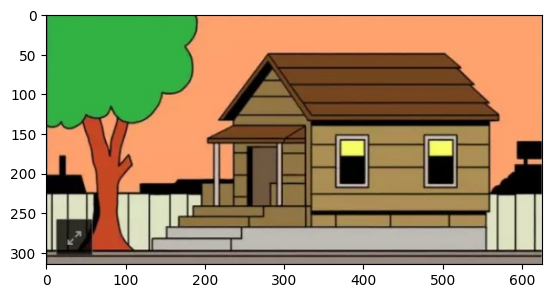

In [7]:
img = cv2.imread('example.jpg')
plt.imshow(img[:,:,::-1])

2. Harris Corner Detection

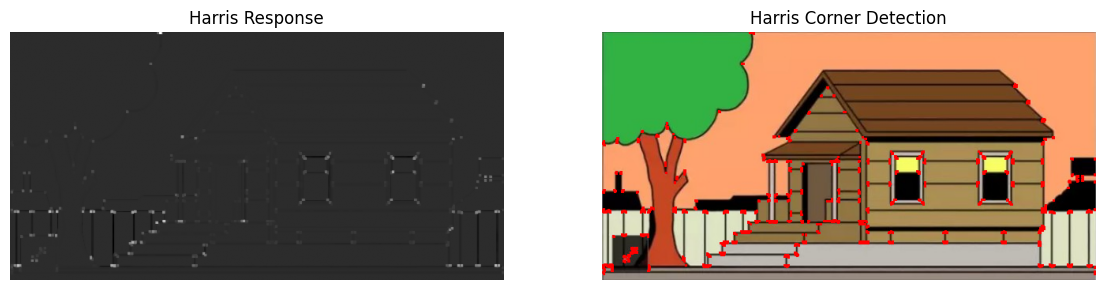

In [8]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_float = np.float32(gray)

harris_response = cv2.cornerHarris(gray_float, 2, 3, 0.04)

# Làm nổi response để hiển thị đẹp hơn
harris_response = cv2.dilate(harris_response, None)

# Vẽ corner lên ảnh
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_harris = img_rgb.copy()
threshold = 0.01 * harris_response.max()
img_harris[harris_response > threshold] = [255, 0, 0]  # tô đỏ corner

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(harris_response, cmap='gray')
plt.title("Harris Response")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_harris)
plt.title("Harris Corner Detection")
plt.axis("off")

plt.show()

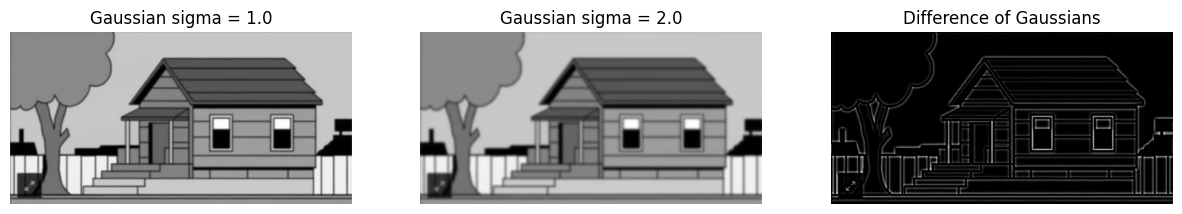

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as PhuongMai

# Đọc ảnh
img = cv2.imread('example.jpg') # Changed 'hinh1.jpg' to 'example.jpg'
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Gaussian blur với hai sigma khác nhau
blur_small = cv2.GaussianBlur(gray, (0,0), 1.0)
blur_large = cv2.GaussianBlur(gray, (0,0), 2.0)

# Difference of Gaussians
dog = cv2.subtract(blur_small, blur_large)

# Hiển thị kết quả
PhuongMai.figure(figsize=(15,5))

PhuongMai.subplot(1,3,1)
PhuongMai.imshow(blur_small, cmap='gray')
PhuongMai.title("Gaussian sigma = 1.0")
PhuongMai.axis("off")

PhuongMai.subplot(1,3,2)
PhuongMai.imshow(blur_large, cmap='gray')
PhuongMai.title("Gaussian sigma = 2.0")
PhuongMai.axis("off")

PhuongMai.subplot(1,3,3)
PhuongMai.imshow(dog, cmap='gray')
PhuongMai.title("Difference of Gaussians")
PhuongMai.axis("off")

PhuongMai.show()

4. Automatic Scale Selection

Best scale sigma = 5.0


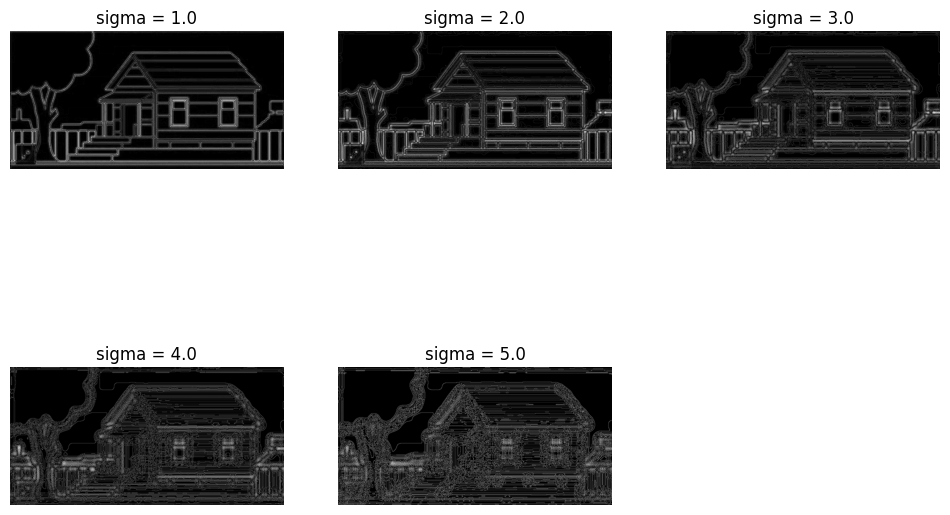

In [11]:
scales = [1.0, 2.0, 3.0, 4.0, 5.0]
responses = []
max_values = []

for sigma in scales:

    blur = cv2.GaussianBlur(gray, (0,0), sigma)

    lap = cv2.Laplacian(blur, cv2.CV_64F)

    normalized = (sigma**2) * np.abs(lap)

    responses.append(normalized)
    max_values.append(normalized.max())

best_scale_index = np.argmax(max_values)
best_sigma = scales[best_scale_index]

print("Best scale sigma =", best_sigma)

PhuongMai.figure(figsize=(12,8))

for i, sigma in enumerate(scales):

    PhuongMai.subplot(2,3,i+1)
    PhuongMai.imshow(responses[i], cmap='gray')
    PhuongMai.title("sigma = " + str(sigma))
    PhuongMai.axis("off")

PhuongMai.show()

5. Scale Invariant Detection (SIFT)

Number of keypoints = 766


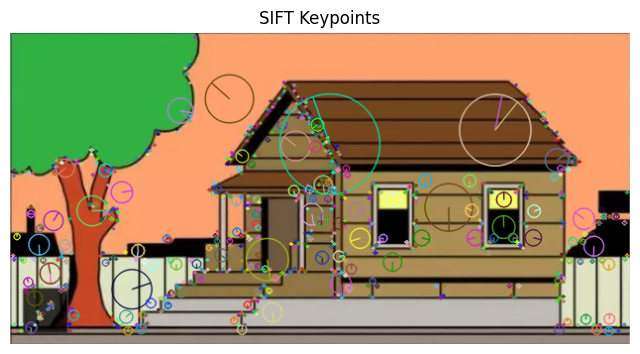

In [13]:
# Tạo SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints
keypoints, descriptors = sift.detectAndCompute(gray, None)

# Vẽ keypoints
img_sift = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_sift = cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB)

print("Number of keypoints =", len(keypoints))

PhuongMai.figure(figsize=(8,6))
PhuongMai.imshow(img_sift)
PhuongMai.title("SIFT Keypoints")
PhuongMai.axis("off")
PhuongMai.show()

6. Scale-space blob detector

Number of blobs detected = 6


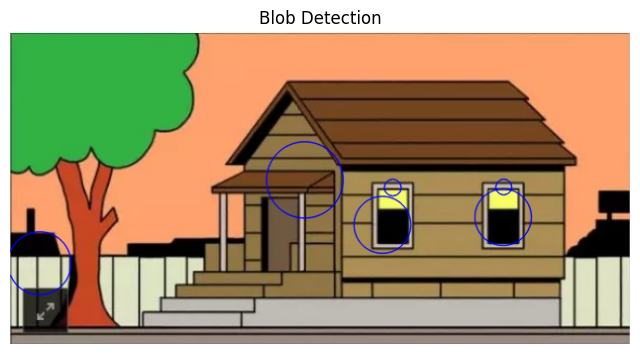

In [12]:
params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True
params.minArea = 50

params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

detector = cv2.SimpleBlobDetector_create(params)

keypoints = detector.detect(gray)

img_blob = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    (255,0,0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_blob = cv2.cvtColor(img_blob, cv2.COLOR_BGR2RGB)

print("Number of blobs detected =", len(keypoints))

PhuongMai.figure(figsize=(8,6))
PhuongMai.imshow(img_blob)
PhuongMai.title("Blob Detection")
PhuongMai.axis("off")
PhuongMai.show()

7. Thực hành với Bag-of-Words detection

Số lượng keypoints = 766
Histogram Bag-of-Words:
[55 49 30 16 45 15 45 74 36 23 30 51 37 32 50 57 55 20 16 30]


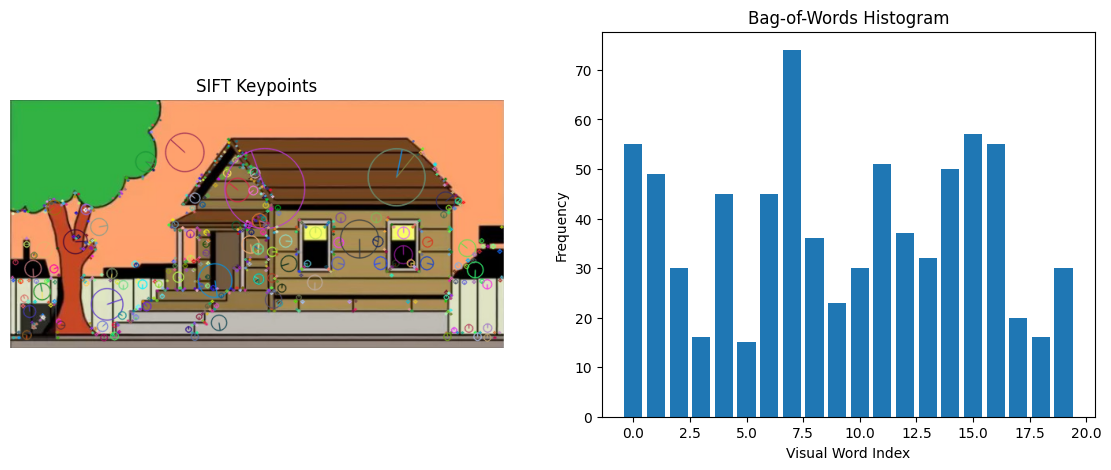

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as PhuongMai
from sklearn.cluster import KMeans

# Đọc ảnh
img = cv2.imread('example.jpg') # Changed from 'hinh1.jpg'
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Tạo SIFT
sift = cv2.SIFT_create()

# Tìm keypoints và descriptors
keypoints, descriptors = sift.detectAndCompute(gray, None)

if descriptors is None or len(descriptors) == 0:
    print("Không tìm thấy descriptors.")
else:
    # Chọn số cụm visual words
    k = 20
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(descriptors)

    # Gán mỗi descriptor vào 1 cụm
    labels = kmeans.predict(descriptors)

    # Tạo histogram Bag-of-Words
    bow_hist = np.bincount(labels, minlength=k)

    print("Số lượng keypoints =", len(keypoints))
    print("Histogram Bag-of-Words:")
    print(bow_hist)

    # Hiển thị keypoints
    img_kp = cv2.drawKeypoints(
        img,
        keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    img_kp = cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB)

    PhuongMai.figure(figsize=(14, 5))

    PhuongMai.subplot(1, 2, 1)
    PhuongMai.imshow(img_kp)
    PhuongMai.title("SIFT Keypoints")
    PhuongMai.axis("off")

    PhuongMai.subplot(1, 2, 2)
    PhuongMai.bar(range(k), bow_hist)
    PhuongMai.title("Bag-of-Words Histogram")
    PhuongMai.xlabel("Visual Word Index")
    PhuongMai.ylabel("Frequency")

    PhuongMai.show()

8. Ghép ảnh Image Panoramas

In [16]:
img1 = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

if img1 is None or img2 is None:
    print("Không tìm thấy hinh1.jpg hoặc hinh2.jpg")
else:
    stitcher = cv2.Stitcher_create()
    status, panorama = stitcher.stitch([img1, img2])

    print("Stitching status =", status)

    if status == cv2.Stitcher_OK:
        panorama_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)

        PhuongMai.figure(figsize=(12, 6))
        PhuongMai.imshow(panorama_rgb)
        PhuongMai.title("Image Panorama")
        PhuongMai.axis("off")
        PhuongMai.show()
    else:
        print("Ghép panorama thất bại.")

Không tìm thấy hinh1.jpg hoặc hinh2.jpg


9. Ghép ảnh Automatic mosaicing

Số lượng good matches = 53


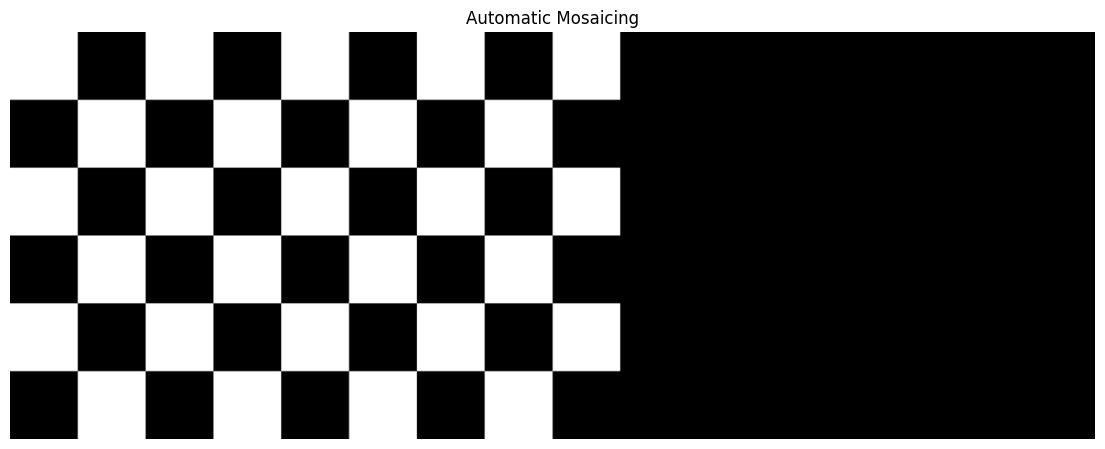

In [18]:
img1 = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

if img1 is None or img2 is None:
    print("Không tìm thấy hinh1.jpg hoặc hinh2.jpg")
else:
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        print("Không tìm thấy đặc trưng để ghép ảnh.")
    else:
        bf = cv2.BFMatcher()
        matches = bf.knnMatch(des1, des2, k=2)

        good_matches = []
        for m, n in matches:
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

        print("Số lượng good matches =", len(good_matches))

        if len(good_matches) >= 4:
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

            H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

            height1, width1 = img1.shape[:2]
            height2, width2 = img2.shape[:2]

            result = cv2.warpPerspective(img1, H, (width1 + width2, max(height1, height2)))
            result[0:height2, 0:width2] = img2

            result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

            PhuongMai.figure(figsize=(14, 6))
            PhuongMai.imshow(result_rgb)
            PhuongMai.title("Automatic Mosaicing")
            PhuongMai.axis("off")
            PhuongMai.show()
        else:
            print("Không đủ matches để ghép ảnh.")

10. Sử dụng Wide base-line stereo

Số lượng good matches = 53


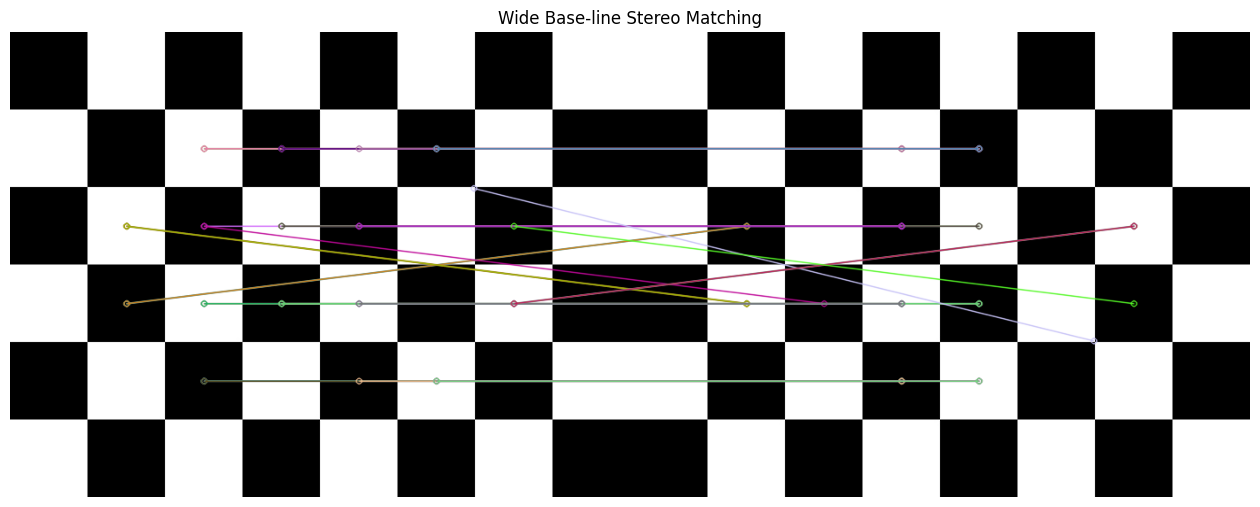

In [19]:
img1 = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

if img1 is None or img2 is None:
    print("Không tìm thấy hinh1.jpg hoặc hinh2.jpg")
else:
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        print("Không tìm thấy descriptors.")
    else:
        bf = cv2.BFMatcher()
        matches = bf.knnMatch(des1, des2, k=2)

        good_matches = []
        for m, n in matches:
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

        print("Số lượng good matches =", len(good_matches))

        match_img = cv2.drawMatches(
            img1, kp1,
            img2, kp2,
            good_matches[:50],
            None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )

        match_img = cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB)

        PhuongMai.figure(figsize=(16, 8))
        PhuongMai.imshow(match_img)
        PhuongMai.title("Wide Base-line Stereo Matching")
        PhuongMai.axis("off")
        PhuongMai.show()

11. CBIR (content-based image retrieval)

In [21]:
import os

# Danh sách ảnh trong tập dữ liệu
image_files = ['hinh1.jpg', 'hinh2.jpg', 'hinh3.png', 'hinh4.png']

def extract_color_histogram(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist = cv2.calcHist([hsv], [0, 1], None, [8, 8], [0, 180, 0, 256])
    hist = cv2.normalize(hist, hist).flatten()

    return hist

# Ảnh truy vấn
query_image = 'hinh1.jpg'
query_hist = extract_color_histogram(query_image)

if query_hist is None:
    print("Không đọc được ảnh truy vấn.")
else:
    scores = []

    for file in image_files:
        hist = extract_color_histogram(file)
        if hist is not None:
            similarity = cv2.compareHist(
                query_hist.astype('float32'),
                hist.astype('float32'),
                cv2.HISTCMP_CORREL
            )
            scores.append((file, similarity))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    print("Kết quả truy xuất ảnh theo nội dung:")
    for file, score in scores:
        print(file, ":", score)

Kết quả truy xuất ảnh theo nội dung:
hinh1.jpg : 1.0
hinh2.jpg : 1.0
hinh3.png : 1.0
hinh4.png : 0.9999999999999999


12. Bag-of-word with SIFT + Histogram

Ma trận đặc trưng Bag-of-Words:
hinh1.jpg -> [0.01369863 0.         0.10958904 0.0890411  0.08219178 0.
 0.08219178 0.0890411  0.04109589 0.         0.01369863 0.
 0.         0.         0.10958904 0.         0.05479452 0.
 0.04109589 0.05479452 0.         0.05479452 0.04109589 0.04109589
 0.04109589 0.         0.01369863 0.         0.01369863 0.01369863]
hinh2.jpg -> [0.01351351 0.         0.10810811 0.07432432 0.10135135 0.
 0.10135135 0.07432432 0.04054054 0.         0.01351351 0.
 0.         0.         0.10810811 0.         0.05405405 0.
 0.04054054 0.05405405 0.         0.05405405 0.04054054 0.04054054
 0.04054054 0.         0.01351351 0.         0.01351351 0.01351351]
hinh3.png -> [0.        0.078125  0.        0.        0.        0.046875  0.
 0.        0.        0.0234375 0.        0.03125   0.0390625 0.71875
 0.        0.046875  0.        0.0078125 0.        0.        0.
 0.        0.        0.        0.        0.0078125 0.        0.
 0.        0.       ]
hinh4.png -> [0.      

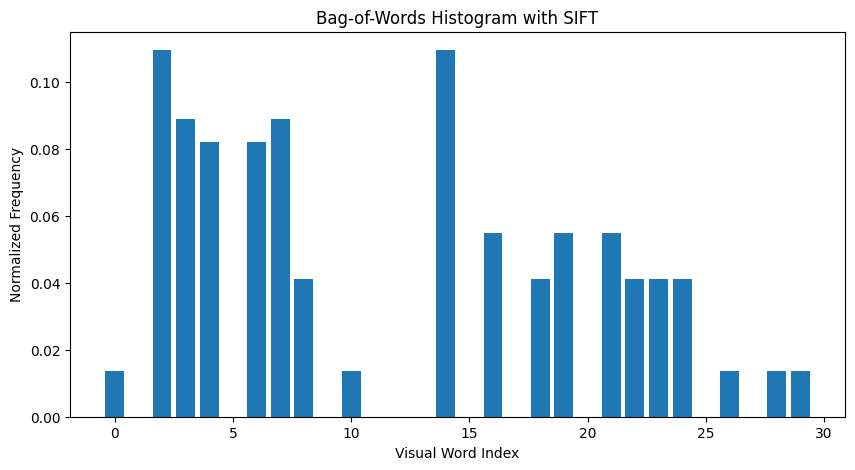

In [22]:
from sklearn.cluster import KMeans

image_files = ['hinh1.jpg', 'hinh2.jpg', 'hinh3.png', 'hinh4.png']
all_descriptors = []
image_descriptor_list = []

sift = cv2.SIFT_create()

for file in image_files:
    img = cv2.imread(file)
    if img is None:
        image_descriptor_list.append(None)
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(gray, None)

    image_descriptor_list.append(des)

    if des is not None:
        all_descriptors.extend(des)

all_descriptors = np.array(all_descriptors)

if len(all_descriptors) == 0:
    print("Không có descriptors để tạo Bag-of-Words.")
else:
    k = 30
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(all_descriptors)

    bow_features = []

    for des in image_descriptor_list:
        if des is None:
            hist = np.zeros(k)
        else:
            labels = kmeans.predict(des)
            hist = np.bincount(labels, minlength=k)

        hist = hist / (hist.sum() + 1e-7)
        bow_features.append(hist)

    print("Ma trận đặc trưng Bag-of-Words:")
    for i, hist in enumerate(bow_features):
        print(image_files[i], "->", hist)

    # Hiển thị histogram của ảnh đầu tiên
    PhuongMai.figure(figsize=(10, 5))
    PhuongMai.bar(range(k), bow_features[0])
    PhuongMai.title("Bag-of-Words Histogram with SIFT")
    PhuongMai.xlabel("Visual Word Index")
    PhuongMai.ylabel("Normalized Frequency")
    PhuongMai.show()